In [1]:
import pyscan as ps
from pyscan.drivers.thorlabs.thorlabspm16_120 import ThorlabsPM16_120

import numpy as np
from time import sleep
import matplotlib.pyplot as plt

In [5]:
devices = ps.ItemAttribute()


devices.x1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 1)
devices.y1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 2)

devices.x2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 1)
devices.y2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 2)

devices.pm16_120 = ThorlabsPM16_120()

devices.laser = ps.PulseLaser('COM7')


COM7


In [8]:
def measure_power(expt):

    d = ps.ItemAttribute()

    d.power = devices.pm16_120.power

    return d


In [54]:
devices.x1.voltage = 0
devices.y1.voltage = 0
devices.x2.voltage = 0
devices.y2.voltage = 0

In [66]:
runinfo = ps.RunInfo()

runinfo.measure_function = measure_power

runinfo.scan0 = ps.PropertyScan({'x1': ps.drange(1.4, 0.002, 1.8)}, prop='voltage', dt=0.01)
runinfo.scan1 = ps.RepeatScan(2)

# runinfo.scan1 = ps.PropertyScan({'y1': ps.drange(-0.5, 0.05, 0.5)}, prop='voltage', dt=0.05)

expt = ps.Experiment(runinfo, devices)

expt.start_thread()


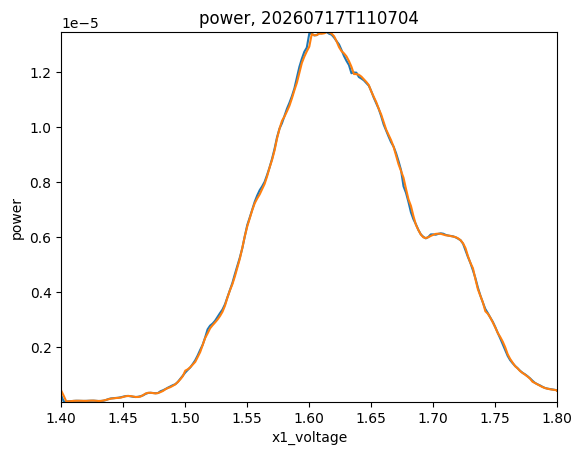

In [67]:
try:
    ps.live_plot1D(expt)
except KeyboardInterrupt:
    expt.stop()

1.3348119e-05 1.6 0.0 0.0 0.0
1.3325753e-05 1.6 -0.02 0.0 0.0
1.3253041e-05 1.6 -0.02 0.0 0.0
1.3282299e-05 1.6 -0.02 0.0 -0.02
1.3306536e-05 1.6 -0.02 0.0 -0.02
1.3296839e-05 1.6 -0.03 0.0 -0.02
1.3307555e-05 1.6 -0.03 0.0 -0.02
1.3267759e-05 1.6 -0.03 0.0 -0.02
1.3434862e-05 1.59 -0.03 0.0 -0.02
1.3761077e-05 1.59 0.04 0.0 -0.02
1.3895868e-05 1.59 0.04 -0.01 -0.02
1.3751048e-05 1.59 0.04 -0.01 -0.02


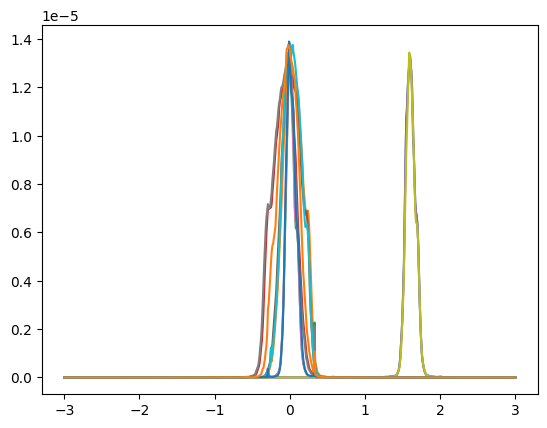

In [48]:
for i in range(3):
    for axis in ['x1', 'y1', 'x2', 'y2']:
        devices[axis].voltage = -3
        sleep(0.5)

        runinfo = ps.RunInfo()

        runinfo.measure_function = measure_power

        runinfo.scan0 = ps.PropertyScan({axis: ps.drange(-3, 0.01, 3)}, prop='voltage', dt=0.05)

        expt = ps.Experiment(runinfo, devices)

        expt.run()

        devices[axis].voltage = expt['{}_voltage'.format(axis)][np.argmax(expt.power)]

        plt.plot( expt['{}_voltage'.format(axis)], expt.power)
        print(np.max(expt.power), devices.x1.voltage, devices.y1.voltage, devices.x2.voltage, devices.y2.voltage)
        sleep(1)

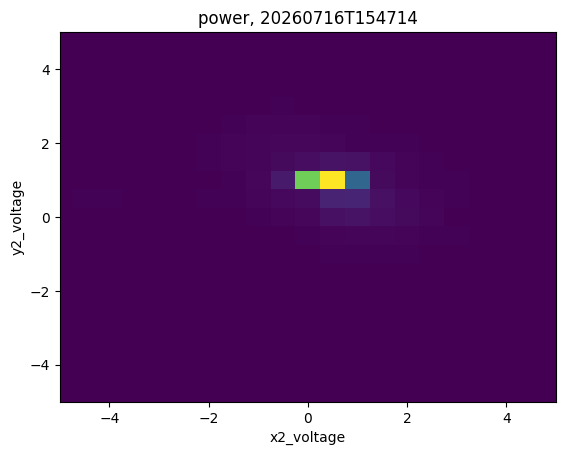

In [25]:
try:
    ps.live_plot2D(expt)
except KeyboardInterrupt:
    expt.stop()

C:\Users\quantumdefects\AppData\Local\Temp\ipykernel_10248\1791459392.py:1: RuntimeWarning: invalid value encountered in log
  plt.pcolormesh(np.log(expt.power))


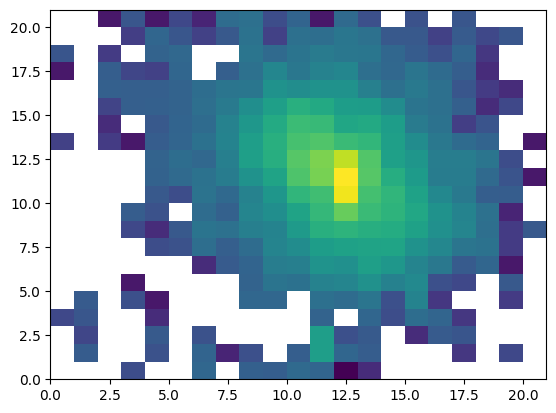

In [29]:
plt.pcolormesh(np.log(expt.power))